In [1]:
# Importing Libraries
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict, Annotated
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from pydantic import BaseModel, Field
import operator
import os
from pprint import pprint

from dotenv import load_dotenv
load_dotenv()

True

In [2]:
# Defining LLM Model
MODEL_NAME = 'gpt-4o-mini'
model = ChatOpenAI(model=MODEL_NAME)

# Structured output
class Evaluator(BaseModel):
    feedback: str = Field(description='Feedback for the given essay in bullet points')
    score: int = Field(description='Score the essay out of 10', ge=0, le=10)

# Assigne the structured output for the model
structured_model = model.with_structured_output(Evaluator)

In [3]:
essay_file_path = 'essay.txt' # available in the same directory

# reading the essay
with open(essay_file_path, 'r') as file:
    essay = file.read()

In [12]:
# Define state
class EvaluatorState(TypedDict):
    essay:str
    language_feedback:str 
    thought_feedback:str 
    analysis_feedback:str
    overall_feedback:str 
    individual_score:Annotated[list[int], operator.add]
    final_score:int

In [13]:
evaluation_prompt = PromptTemplate(template='Evaluate the {evaluation_task} of the following essay and provide a feedback and assign a score out of 10 \n {essay}',
                                   input_variables=['evaluation_task', 'essay'])

In [24]:
def thought_evaluation(state:EvaluatorState)-> EvaluatorState:
    prompt = evaluation_prompt.invoke({
        'evaluation_task': 'clearity of thought',
        'essay': state['essay']
    })
    output = structured_model.invoke(prompt)

    return {'thought_feedback': output.feedback, 'individual_score': [output.score]}

def language_evaluation(state:EvaluatorState)-> EvaluatorState:
    prompt = evaluation_prompt.invoke(
        {'evaluation_task': 'language quality',
        'essay': state['essay']}
    )
    output = structured_model.invoke(prompt)
    return {'language_feedback': output.feedback, 'individual_score': [output.score]}

def analysis_evaluation(state:EvaluatorState)-> EvaluatorState:
    prompt = evaluation_prompt.invoke({ 
        'evaluation_task': 'depth of analysis',
        'essay': state['essay']})
    
    output = structured_model.invoke(prompt)
    return {'analysis_feedback': output.feedback, 'individual_score': [output.score]}

def final_evaluation(state: EvaluatorState)-> EvaluatorState:
    prompt_template = PromptTemplate(
        template='Based on the following feedbacks create a summarized feedback \n language feedback - {language_feedback} \n depth of analysis feedback - {analysis_feedback} \n clarity of thought feedback - {thought_feedback}',
        input_variables=['language_feedback', 'analysis_feedback', 'thought_feedback']
    )

    prompt = prompt_template.invoke({
        'language_feedback': state['language_feedback'],
        'analysis_feedback': state['analysis_feedback'],
        'thought_feedback': state['thought_feedback']
    })

    output = structured_model.invoke(prompt)

    # calculate avg score
    avg_score = int(sum(state['individual_score'])/len(state['individual_score']))
    return {'overall_feedback': output.feedback, 'final_score': avg_score}

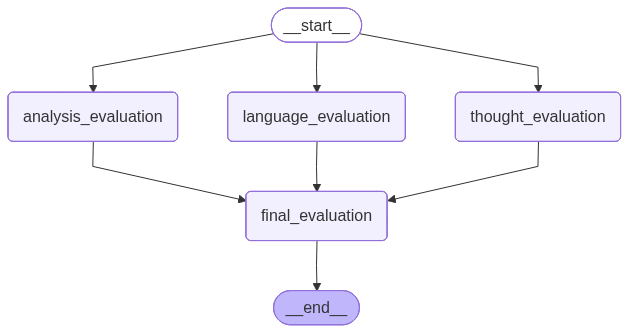

In [25]:
# Define the graph
graph = StateGraph(EvaluatorState)

# Define the nodes
graph.add_node('thought_evaluation', thought_evaluation)
graph.add_node('language_evaluation', language_evaluation)
graph.add_node('analysis_evaluation', analysis_evaluation)
graph.add_node('final_evaluation', final_evaluation)

# Define the edges
graph.add_edge(START, 'thought_evaluation')
graph.add_edge(START, 'language_evaluation')
graph.add_edge(START, 'analysis_evaluation')

graph.add_edge('thought_evaluation', 'final_evaluation')
graph.add_edge('language_evaluation', 'final_evaluation')
graph.add_edge('analysis_evaluation', 'final_evaluation')

graph.add_edge('final_evaluation', END)

# compile and visualize the graph
workflow = graph.compile()
workflow

In [26]:
# Testing
intial_state = {'essay': essay}

final_state = workflow.invoke(intial_state)

In [27]:
final_state

{'essay': "# The Rise of AI in India\n\n## Introduction\n\nDid you know that the artificial intelligence (AI) market in India is expected to reach a staggering $7.8 billion by 2025? This explosive growth reflects not just an increase in interest but also significant investments and innovations within the country. AI, a subset of computer science that empowers machines to mimic human intelligence, has become a global leader in enhancing productivity, efficiency, and decision-making.\n\nIn recent years, India has emerged as a critical player in the global AI landscape, leveraging its vast data resources, technical talent, and robust talent pool to drive advancements in AI technologies. This blog will explore the current state of AI in India, sectors leading the charge, challenges faced, future projections, and the crucial role of government, academia, and industry in shaping this exciting field.\n\n## Section 1: The Current State of AI in India\n\n### 1.1 Overview of AI Development\n\nAI

In [30]:
pprint(final_state, indent=1, width=100)

{'analysis_feedback': '- The essay covers a wide range of topics concerning AI in India, providing '
                      'a thorough overview of the current landscape and future projections.\n'
                      '- The structure of the essay is clear and organized into relevant sections, '
                      'which makes it easy to follow.\n'
                      '- It includes specific examples of companies and initiatives, which helps '
                      'to illustrate the points being made and adds credibility to the analysis.\n'
                      '- The discussion around challenges and future projections demonstrates a '
                      "good balance between optimism for AI's potential and realism about the "
                      'hurdles that need to be overcome.\n'
                      '- The conclusion effectively summarizes the key points and emphasizes the '
                      'importance of stakeholder engagement, leaving the reader with a sense o